# Vežbe 4: Višestruka linearna regresija pomoću neuronske mreže u biblioteci PyTorch

U ovom notebook-u fokus je na **višestrukoj linearnoj regresiji** nad realnim skupom podataka iz CSV fajla.

Cilj je da kroz ovaj primer prikažemo:
- rad sa realnim skupom podataka,
- osnovnu pripremu podataka pomoću biblioteke `scikit-learn`,
- definisanje modela u biblioteci `PyTorch`,
- mini-batch treniranje pomoću `DataLoader` klase,
- evaluaciju modela,
- čuvanje i ponovno učitavanje istreniranog modela.


In [75]:
# Import potrebnih biblioteka

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader

## 1. Postavljanje seed-a za reproduktivnost rezultata

In [76]:
# Postaviti seed za NumPy i PyTorch

torch.manual_seed(42)
np.random.seed(42)

## 2. Učitavanje skupa podataka

In [77]:
# Učitati CSV fajl boston.csv

df = pd.read_csv("boston.csv")

# Prikazati prvih nekoliko redova

df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


## 3. Osnovni pregled podataka

In [78]:
# Prikazati osnovne informacije o kolonama i tipovima podataka

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       501 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [79]:
# Prikazati deskriptivnu statistiku numeričkih atributa

df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,501.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284341,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.705587,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.884000,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208000,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.625000,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [80]:
# Proveriti da li postoje nedostajuće vrednosti

print("Broj nedostajućih vrednosti po kolonama:")
print(df.isna().sum())

Broj nedostajućih vrednosti po kolonama:
crim       0
zn         0
indus      0
chas       0
nox        0
rm         5
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64


In [81]:
# Izbaciti sve redove koji imaju NaN u bilo kojoj koloni
df = df.dropna() #df.dropna(inplace=True)

## 4. Razdvajanje ulaznih atributa i ciljne varijable

In [82]:
# Formirati matricu ulaznih atributa X i ciljnu varijablu y

X = df.drop(columns=["medv"])
y = df["medv"]

## 5. Podela na trening i test skup

In [83]:
# Podeliti podatke na trening i test skup uz korišćenje stratifikacije

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=pd.qcut(df["medv"], q=10, duplicates="drop")
)

# Prikazati dimenzije trening i test skupa

print("Dimenzije trening skupa:", X_train.shape, y_train.shape)
print("Dimenzije test skupa:", X_test.shape, y_test.shape)

Dimenzije trening skupa: (400, 13) (400,)
Dimenzije test skupa: (101, 13) (101,)


## 6. Standardizacija ulaznih atributa

In [84]:
# Kreirati objekat za standardizaciju i primeniti ga na trening i test skup

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 7. Konverzija u tenzore

In [85]:
# Pretvoriti ulazne podatke i ciljne vrednosti u PyTorch tenzore tipa float32

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.to_numpy(), dtype=torch.float32).reshape(-1, 1)
y_test_tensor = torch.tensor(y_test.to_numpy(), dtype=torch.float32).reshape(-1, 1)

print("Dimenzije X_train_tensor:", X_train_tensor.shape)
print("Dimenzije y_train_tensor:", y_train_tensor.shape)

Dimenzije X_train_tensor: torch.Size([400, 13])
Dimenzije y_train_tensor: torch.Size([400, 1])


## 8. Kreiranje batch-eva pomoću DataLoader-a

In [86]:
# Formirati TensorDataset i DataLoader za mini-batch treniranje

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

# Prikazati broj batch-eva u jednoj epohi

print("Broj batch-eva u jednoj epohi:", len(train_loader))

Broj batch-eva u jednoj epohi: 13


## 9. Definisanje modela

In [87]:
# Definisati klasu neuronske mreže za višestruku linearnu regresiju

class MultipleLinearRegressionModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return self.linear(x)

In [88]:
# Kreirati instancu modela na osnovu broja ulaznih atributa

input_dim = X_train_tensor.shape[1]
model = MultipleLinearRegressionModel(input_dim)

## 10. Prikaz početnih parametara modela

In [89]:
# Prikazati početne vrednosti težina i bias-a modela

print("Početne težine:")
print(model.linear.weight)

print("Početni bias:")
print(model.linear.bias)

Početne težine:
Parameter containing:
tensor([[ 0.2120,  0.2302, -0.0650,  0.2548, -0.0608,  0.0560, -0.1350,  0.1629,
          0.2445, -0.2035,  0.2411,  0.0519,  0.2049]], requires_grad=True)
Početni bias:
Parameter containing:
tensor([0.0376], requires_grad=True)


In [90]:
# Prikazati nazive i dimenzije svih parametara modela

for name, param in model.named_parameters():
    print(name, param.shape)

linear.weight torch.Size([1, 13])
linear.bias torch.Size([1])


## 11. Definisanje funkcije greške i optimizacionog algoritma

In [91]:
# Definisati MSE funkciju greške i SGD optimizacioni algoritam

criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

## 12. Trening modela

In [92]:
# Istrenirati model korišćenjem mini-batch pristupa i čuvati prosečnu grešku po epohi

num_epochs = 200
train_losses = []

model.train()

for epoch in range(num_epochs):
    epoch_loss = 0.0

    for X_batch, y_batch in train_loader:
        # Predikcija modela nad jednim batch-em
        y_pred_batch = model(X_batch)

        # Izračunavanje greške
        loss = criterion(y_pred_batch, y_batch)

        # Brisanje prethodnih gradijenata
        optimizer.zero_grad()

        # Izračunavanje gradijenata
        loss.backward()

        # Ažuriranje parametara
        optimizer.step()

        # Sabiranje grešaka po batch-evima
        epoch_loss += loss.item()

    # Izračunavanje prosečne greške po epohi
    avg_epoch_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_epoch_loss)

    # Ispis prosečne greške na svakoj 10. epohi
    if (epoch + 1) % 10 == 0:
        print("Epoha:", epoch + 1, "Prosečna greška:", avg_epoch_loss)

Epoha: 10 Prosečna greška: 28.837321794950046
Epoha: 20 Prosečna greška: 24.311953177818886
Epoha: 30 Prosečna greška: 23.683303612929123
Epoha: 40 Prosečna greška: 22.98322659272414
Epoha: 50 Prosečna greška: 24.207761691166805
Epoha: 60 Prosečna greška: 23.06633156996507
Epoha: 70 Prosečna greška: 22.81786368443416
Epoha: 80 Prosečna greška: 23.34418040055495
Epoha: 90 Prosečna greška: 23.428108362051155
Epoha: 100 Prosečna greška: 23.609896439772385
Epoha: 110 Prosečna greška: 23.265220348651592
Epoha: 120 Prosečna greška: 23.3258518072275
Epoha: 130 Prosečna greška: 24.024212323702297
Epoha: 140 Prosečna greška: 23.017409398005558
Epoha: 150 Prosečna greška: 23.57116523155799
Epoha: 160 Prosečna greška: 23.18605452317458
Epoha: 170 Prosečna greška: 22.81204179617075
Epoha: 180 Prosečna greška: 23.41502864544208
Epoha: 190 Prosečna greška: 23.194891196030838
Epoha: 200 Prosečna greška: 23.06537862924429


## 13. Prikaz greške kroz epohe

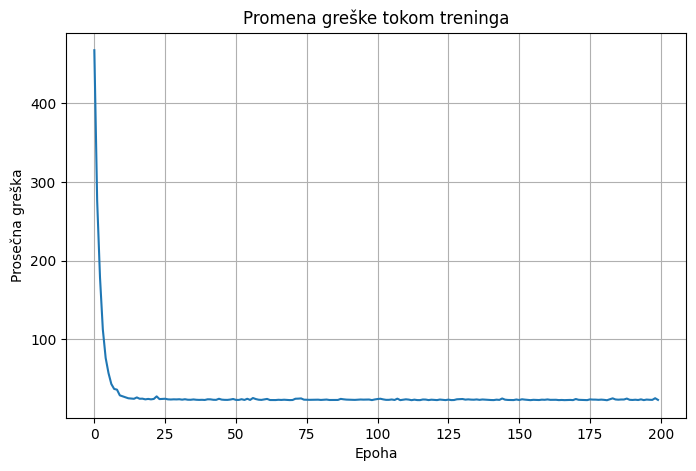

In [93]:
# Nacrtati grafikon promene prosečne greške tokom treninga

plt.figure(figsize=(8, 5))
plt.plot(train_losses)
plt.xlabel("Epoha")
plt.ylabel("Prosečna greška")
plt.title("Promena greške tokom treninga")
plt.grid(True)
plt.show()

## 14. Predikcije modela

In [94]:
# Izračunati predikcije modela nad test skupom

model.eval()

with torch.no_grad():
    y_pred_tensor = model(X_test_tensor)

# Pretvoriti predikcije u NumPy niz

y_pred = y_pred_tensor.numpy()

## 15. Poređenje stvarnih i predikovanih vrednosti

In [95]:
# Formirati dataframe sa stvarnim i predikovanim vrednostima

results_df = pd.DataFrame({
    "Stvarna vrednost": y_test,
    "Predikovana vrednost": y_pred.flatten()
})

# Prikazati prvih 10 redova

results_df.head(10)

,Stvarna vrednost,Predikovana vrednost
495,23.1,16.231606
171,19.1,24.770826
351,24.1,20.842516
399,6.3,10.379935
435,13.4,13.043797
12,21.7,20.737068
37,21.0,23.223070
316,17.8,17.491922
41,26.6,27.422153
290,28.5,33.684570


## 16. Evaluacija modela

In [96]:
# Izračunati srednju kvadratnu grešku (MSE)

mse = mean_squared_error(y_test, y_pred)
print("MSE:", round(mse, 4))

MSE: 18.4487


In [97]:
# Izračunati koren srednje kvadratne greške (RMSE)

rmse = np.sqrt(mse)
print("RMSE:", round(rmse, 4))

RMSE: 4.2952


In [98]:
# Izračunati srednju apsolutnu grešku (MAE)

mae = mean_absolute_error(y_test, y_pred)
print("MAE:", round(mae, 4))

MAE: 3.1026


In [99]:
# Izračunati RSS i TSS
y_pred = y_pred.squeeze()

rss = np.sum((y_test - y_pred) ** 2)
tss = np.sum((y_test - np.mean(y_test)) ** 2)

print("RSS:", round(float(rss), 4))
print("TSS:", round(float(tss), 4))

RSS: 1863.3173
TSS: 9095.6275


In [100]:
# Izračunati koeficijent determinacije (R² = 1 - RSS / TSS)

r2 = r2_score(y_test, y_pred)
print("R²:", round(r2, 4))

R²: 0.7951


## 17. Čuvanje istreniranog modela

In [101]:
# Sačuvati parametre istreniranog modela

model_path = "multiple_linear_regression_boston.pth"

torch.save(model.state_dict(), model_path)

print("Model je sačuvan na putanji:", model_path)

Model je sačuvan na putanji: multiple_linear_regression_boston.pth


## 18. Učitavanje sačuvanog modela

In [102]:
# Kreirati novu instancu modela i učitati prethodno sačuvane parametre

loaded_model = MultipleLinearRegressionModel(input_dim)
loaded_model.load_state_dict(torch.load(model_path))
loaded_model.eval()

# Prikazati učitani model

print(loaded_model)

MultipleLinearRegressionModel(
  (linear): Linear(in_features=13, out_features=1, bias=True)
)


## 19. Provera učitanog modela

In [103]:
# Uporediti predikcije originalnog i učitanog modela nad test skupom

with torch.no_grad():
    original_predictions = model(X_test_tensor)
    loaded_predictions = loaded_model(X_test_tensor)

print("Da li su predikcije jednake?")
print(torch.allclose(original_predictions, loaded_predictions))

Da li su predikcije jednake?
True
